C:\Users\am637739\AppData\Local\Temp\ipykernel_9680\276890601.py:141: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f"{key}_YoY"] = df[col].pct_change(12) * 100
C:\Users\am637739\AppData\Local\Temp\ipykernel_9680\276890601.py:142: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f"{key}_MoM"] = df[col].pct_change(1) * 100
C:\Users\am637739\AppData\Local\Temp\ipykernel_9680\276890601.py:141: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fil

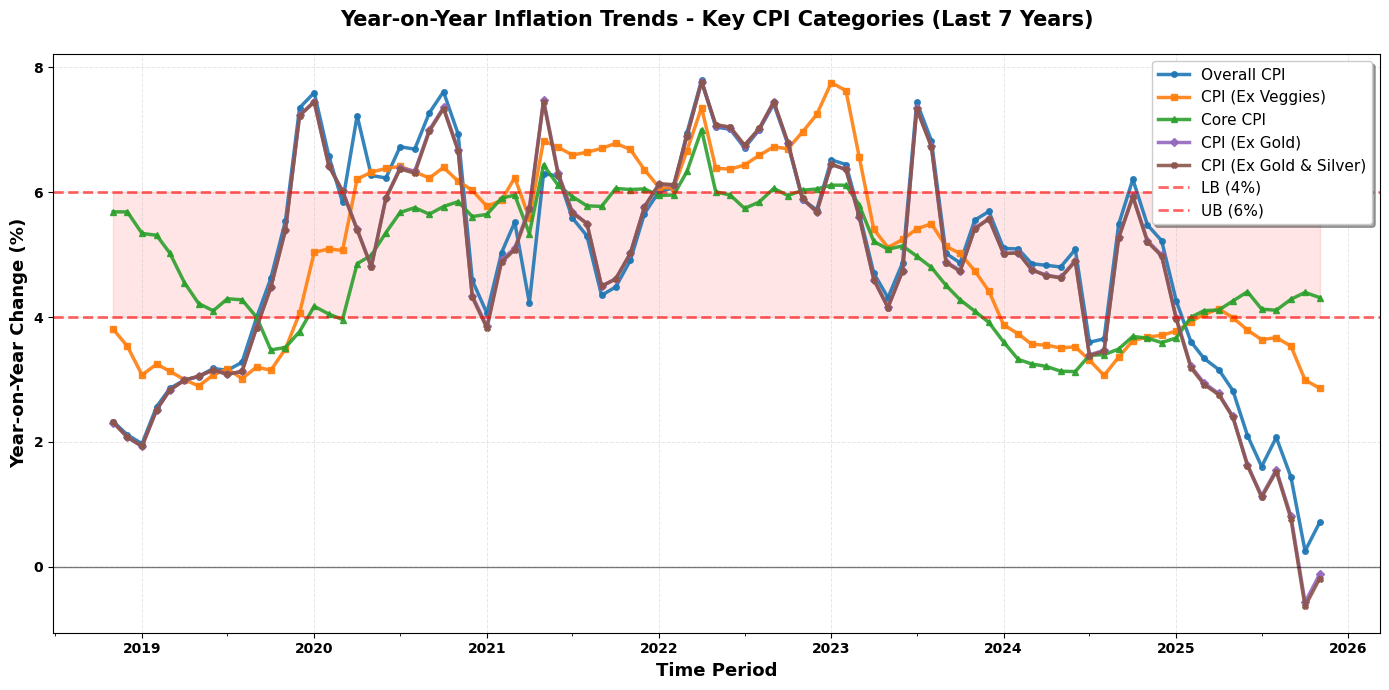

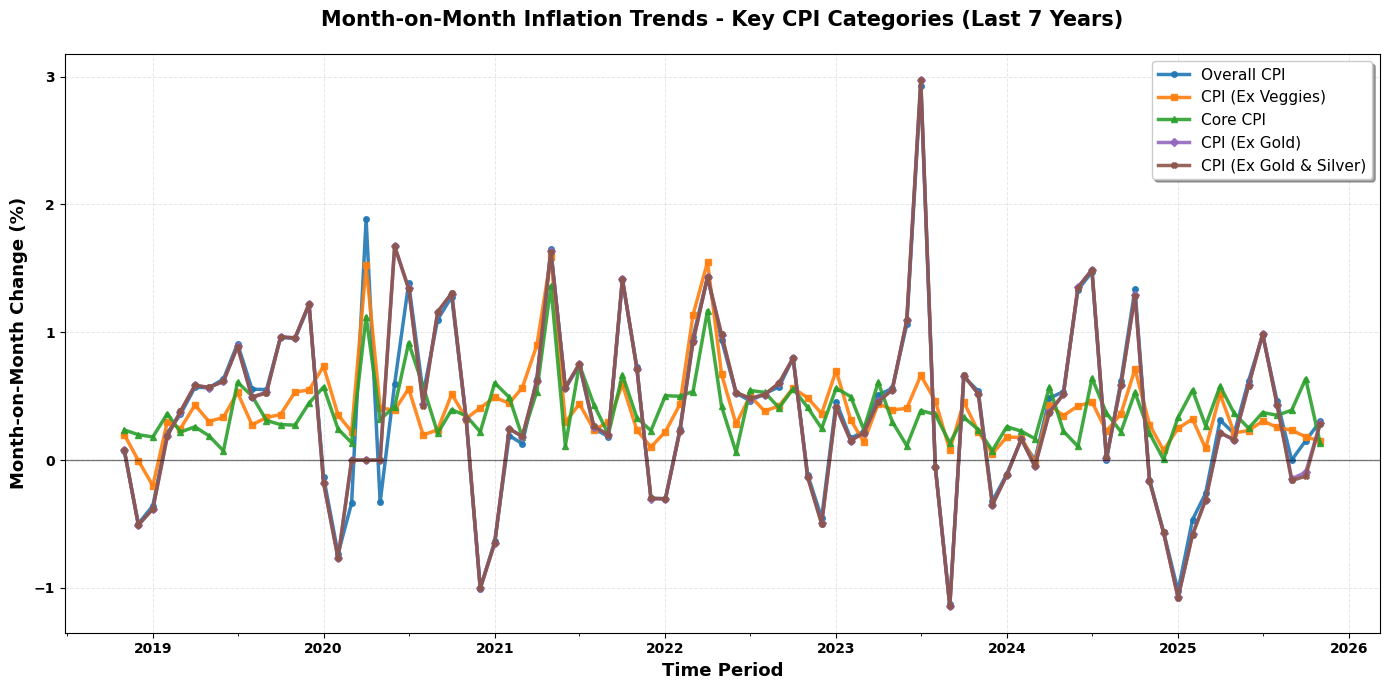

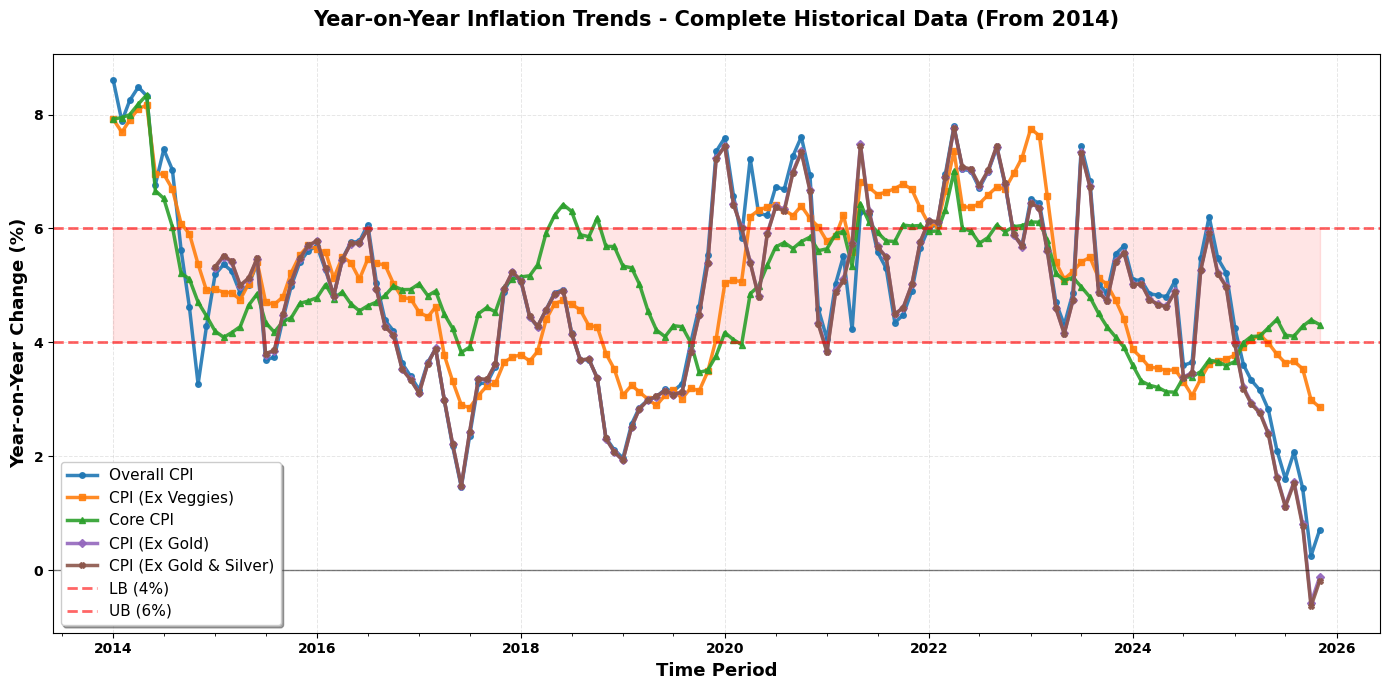

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------
# Load data
# ---------------------------------------------------
df = pd.read_csv("cleaned_inflation_with_calculations.csv")

# ---------------------------------------------------
# Ensure time is datetime and clean
# ---------------------------------------------------
if "time" not in df.columns:
    raise KeyError("Missing required column: 'time'. Make sure your CSV has a 'time' column.")

df = df.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time"]).sort_values("time")

# ---------------------------------------------------
# Helper: robust column finder (generic)
# ---------------------------------------------------
def find_column(df, candidates, must_contain_all=None):
    """
    Finds a column name from a list of candidates (exact match preferred),
    with optional fallback keyword matching.

    - candidates: list[str] exact name candidates
    - must_contain_all: list[str] keywords that must all appear in the column name (case-insensitive)
    """
    # Exact matches first
    for c in candidates:
        if c in df.columns:
            return c

    # Fallback: keyword-based matching
    if must_contain_all:
        must_contain_all = [k.lower() for k in must_contain_all]
        matches = []
        for col in df.columns:
            col_l = str(col).lower()
            if all(k in col_l for k in must_contain_all):
                matches.append(col)
        if matches:
            return matches[0]

    raise KeyError(
        "Could not find expected column.\n"
        f"Tried candidates: {candidates}\n"
        f"Keyword rule: {must_contain_all}\n"
        f"Available columns sample: {list(df.columns)[:50]}"
    )

# ---------------------------------------------------
# Resolve CPI columns robustly
# ---------------------------------------------------
col_map = {}

# Overall CPI
col_map["CPI"] = find_column(
    df,
    candidates=[
        "Consumer Price Index",
        "CPI",
        "Overall CPI",
        "All India CPI",
        "Consumer Price Index (CPI)"
    ],
    must_contain_all=["cpi"]  # fallback if naming is unusual
)

# CPI (Ex Veggies)
col_map["ExVeggies"] = find_column(
    df,
    candidates=[
        "CPI (ExVeggies)",
        "CPI (Ex Veggies)",
        "CPI ExVeggies",
        "CPI Ex Veggies",
        "CPI (Ex-Veggies)"
    ],
    must_contain_all=["ex", "vegg"]  # catches veggies/vegetables variants
)

# Core CPI
col_map["Core"] = find_column(
    df,
    candidates=[
        "Core Index",
        "Core CPI",
        "CPI Core",
        "Core Inflation Index"
    ],
    must_contain_all=["core"]
)

# CPI (Ex Gold)
col_map["ExGold"] = find_column(
    df,
    candidates=[
        "CPI (ExGold)",
        "CPI (Ex Gold)",
        "CPI ExGold",
        "CPI Ex Gold",
        "CPI (Ex-Gold)"
    ],
    must_contain_all=["ex", "gold"]
)

# CPI (ExGold and Silver)
col_map["ExGoldSilver"] = find_column(
    df,
    candidates=[
        "CPI (ExGold and Silver)",
        "CPI (ExGold & Silver)",
        "CPI (Ex Gold and Silver)",
        "CPI (Ex Gold & Silver)",
        "CPI (ExGold&Silver)",
        "CPI (Ex Gold&Silver)",
        # In case your file literally contains HTML-escaped header text:
        "CPI (ExGold &amp; Silver)",
        "CPI (Ex Gold &amp; Silver)",
        "CPI (ExGold&amp;Silver)",
        "CPI (Ex Gold&amp;Silver)",
        "CPI (ExGold, Silver)",
        "CPI (Ex Gold, Silver)"
    ],
    must_contain_all=["ex", "gold", "silver"]
)

# ---------------------------------------------------
# Ensure numeric for all mapped columns
# ---------------------------------------------------
for key, col in col_map.items():
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ---------------------------------------------------
# Compute YoY and MoM for all series
# ---------------------------------------------------
for key, col in col_map.items():
    df[f"{key}_YoY"] = df[col].pct_change(12) * 100
    df[f"{key}_MoM"] = df[col].pct_change(1) * 100

# ---------------------------------------------------
# Filters
# ---------------------------------------------------
max_time = df["time"].max()
df_last7 = df[df["time"] >= (max_time - pd.DateOffset(years=7))].copy()
df_full = df[df["time"] >= pd.Timestamp("2014-01-01")].copy()

# ---------------------------------------------------
# Plot settings (colors/markers aligned with your earlier style)
# ---------------------------------------------------
style = {
    "CPI":         dict(color="#1f77b4", marker="o", label="Overall CPI"),
    "ExVeggies":   dict(color="#ff7f0e", marker="s", label="CPI (Ex Veggies)"),
    "Core":        dict(color="#2ca02c", marker="^", label="Core CPI"),
    "ExGold":      dict(color="#9467bd", marker="D", label="CPI (Ex Gold)"),
    "ExGoldSilver":dict(color="#8c564b", marker="X", label="CPI (Ex Gold & Silver)")  # distinct from ExGold
}

def plot_multi(df_plot, value_suffix, title, ylabel, add_rbi_band=False, major_year_step=1):
    fig, ax = plt.subplots(figsize=(14, 7))

    for key in ["CPI", "ExVeggies", "Core", "ExGold", "ExGoldSilver"]:
        ax.plot(
            df_plot["time"], df_plot[f"{key}_{value_suffix}"],
            linewidth=2.5, alpha=0.9,
            markersize=4 if value_suffix == "YoY" else 4,
            **style[key]
        )

    if add_rbi_band:
        ax.axhline(y=4, color="red", linewidth=2, linestyle="--", alpha=0.6, label="LB (4%)")
        ax.axhline(y=6, color="red", linewidth=2, linestyle="--", alpha=0.6, label="UB (6%)")
        ax.fill_between(df_plot["time"], 4, 6, color="red", alpha=0.1)

    ax.set_xlabel("Time Period", fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel, fontweight="bold", fontsize=13)
    ax.set_title(title, fontweight="bold", fontsize=15, pad=20)

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.axhline(y=0, color="black", linewidth=1, linestyle="-", alpha=0.5)

    ax.legend(loc="best", fontsize=11, frameon=True, shadow=True, fancybox=True)

    # Date formatting
    ax.xaxis.set_major_locator(mdates.YearLocator(major_year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Add minor ticks (Jan/Jul) for readability on shorter windows
    ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 7)))

    plt.xticks(rotation=0, ha="center", fontweight="bold")
    plt.yticks(fontweight="bold")

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# Chart 1: YoY (Last 7 Years) + RBI band
# ---------------------------------------------------
plot_multi(
    df_last7,
    value_suffix="YoY",
    title="Year-on-Year Inflation Trends - Key CPI Categories (Last 7 Years)",
    ylabel="Year-on-Year Change (%)",
    add_rbi_band=True,
    major_year_step=1
)

# ---------------------------------------------------
# Chart 2: MoM (Last 7 Years)
# ---------------------------------------------------
plot_multi(
    df_last7,
    value_suffix="MoM",
    title="Month-on-Month Inflation Trends - Key CPI Categories (Last 7 Years)",
    ylabel="Month-on-Month Change (%)",
    add_rbi_band=False,
    major_year_step=1
)

# ---------------------------------------------------
# Chart 3: YoY (Full History from 2014) + RBI band
# ---------------------------------------------------
plot_multi(
    df_full,
    value_suffix="YoY",
    title="Year-on-Year Inflation Trends - Complete Historical Data (From 2014)",
    ylabel="Year-on-Year Change (%)",
    add_rbi_band=True,
    major_year_step=2
)


C:\Users\am637739\AppData\Local\Temp\ipykernel_9680\1230985218.py:114: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f"{key}_YoY"] = df[col].pct_change(12) * 100
C:\Users\am637739\AppData\Local\Temp\ipykernel_9680\1230985218.py:115: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f"{key}_MoM"] = df[col].pct_change(1) * 100


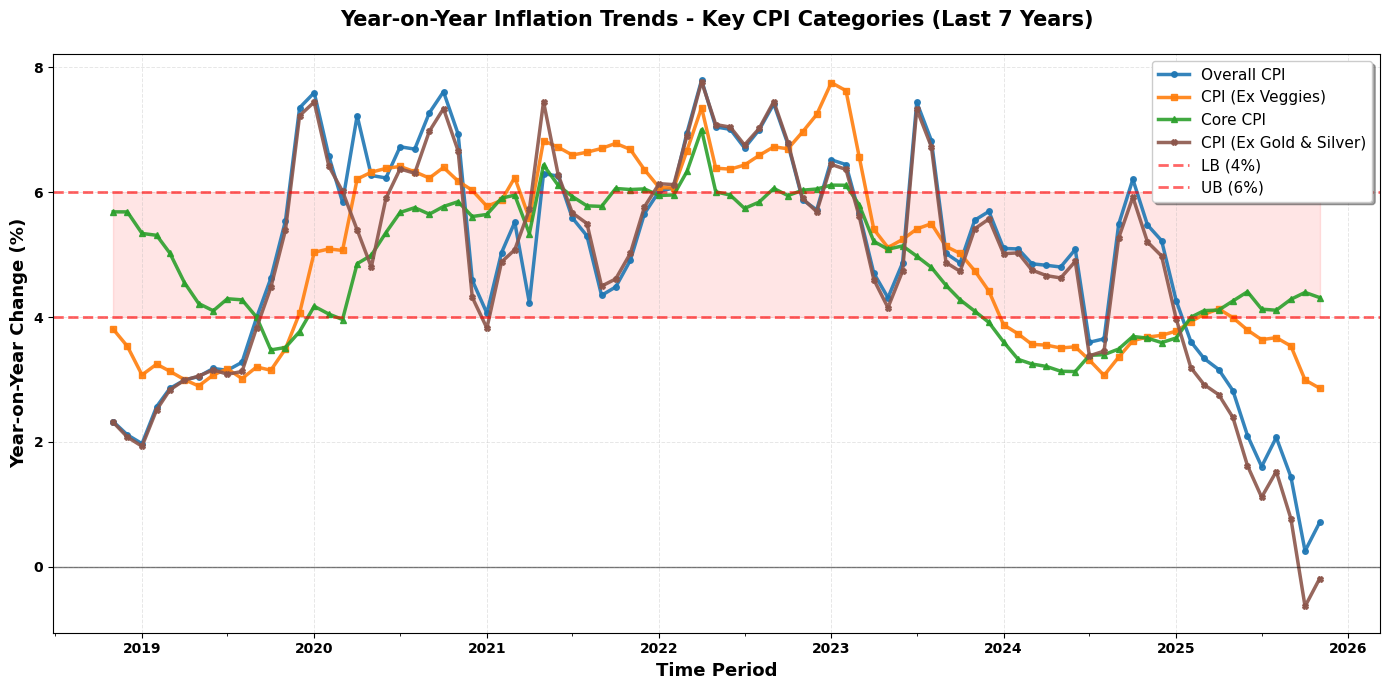

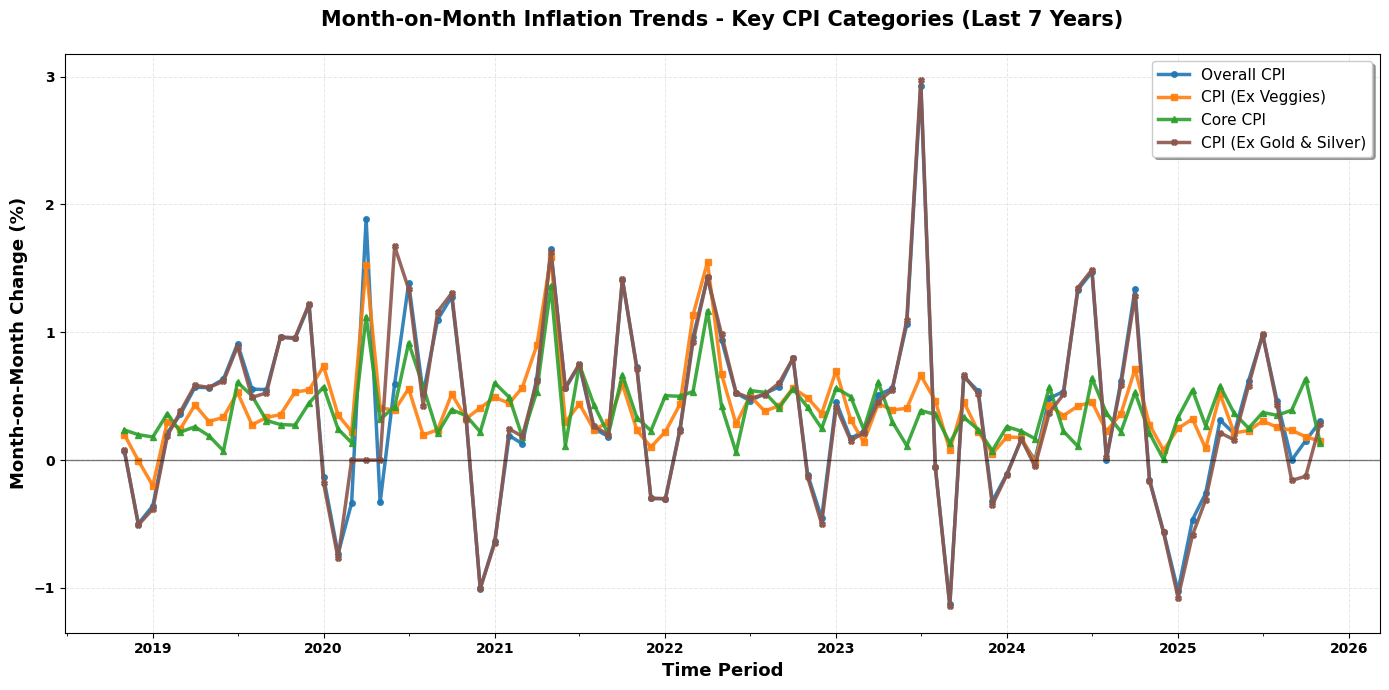

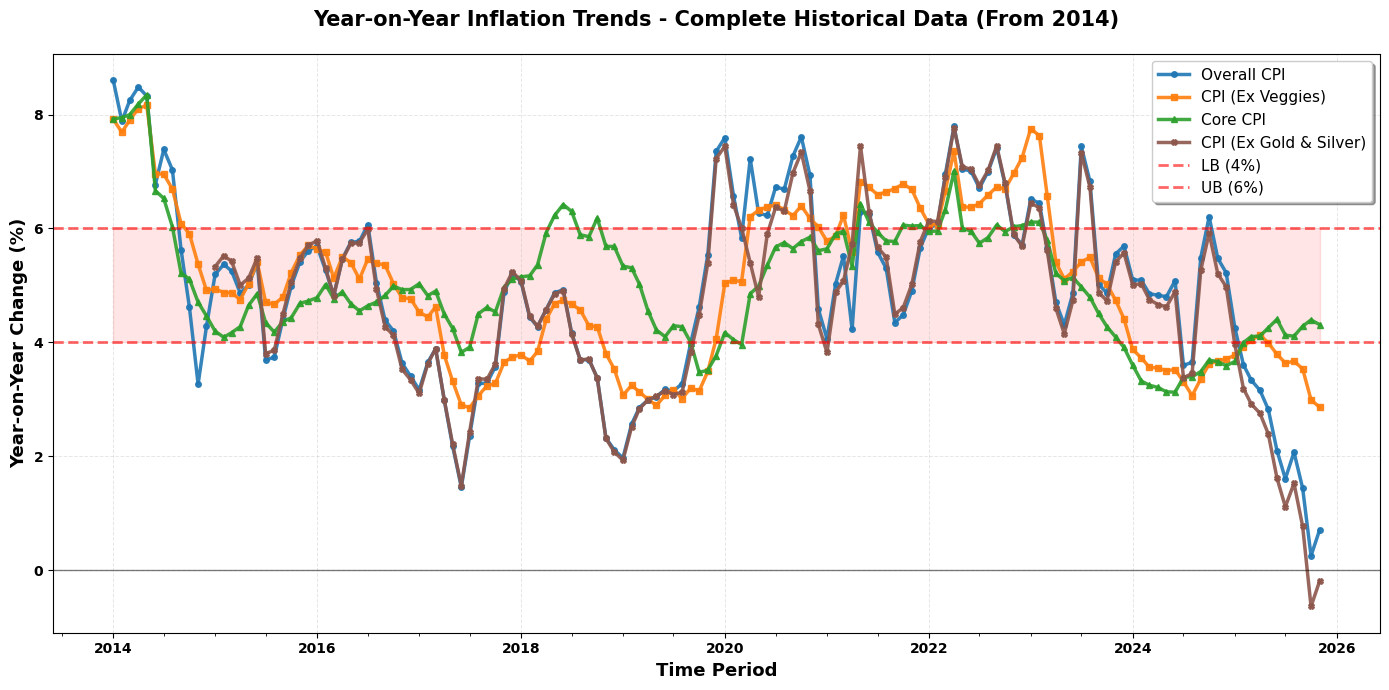

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------
# Load data
# ---------------------------------------------------
df = pd.read_csv("cleaned_inflation_with_calculations.csv")

# ---------------------------------------------------
# Ensure time is datetime and clean
# ---------------------------------------------------
if "time" not in df.columns:
    raise KeyError("Missing required column: 'time'. Make sure your CSV has a 'time' column.")

df = df.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time"]).sort_values("time")

# ---------------------------------------------------
# Helper: robust column finder (generic)
# ---------------------------------------------------
def find_column(df, candidates, must_contain_all=None):
    for c in candidates:
        if c in df.columns:
            return c

    if must_contain_all:
        must_contain_all = [k.lower() for k in must_contain_all]
        matches = []
        for col in df.columns:
            col_l = str(col).lower()
            if all(k in col_l for k in must_contain_all):
                matches.append(col)
        if matches:
            return matches[0]

    raise KeyError(
        "Could not find expected column.\n"
        f"Tried candidates: {candidates}\n"
        f"Keyword rule: {must_contain_all}\n"
        f"Available columns sample: {list(df.columns)[:50]}"
    )

# ---------------------------------------------------
# Resolve CPI columns robustly (ExGold removed)
# ---------------------------------------------------
col_map = {}

col_map["CPI"] = find_column(
    df,
    candidates=[
        "Consumer Price Index",
        "CPI",
        "Overall CPI",
        "All India CPI",
        "Consumer Price Index (CPI)"
    ],
    must_contain_all=["cpi"]
)

col_map["ExVeggies"] = find_column(
    df,
    candidates=[
        "CPI (ExVeggies)",
        "CPI (Ex Veggies)",
        "CPI ExVeggies",
        "CPI Ex Veggies",
        "CPI (Ex-Veggies)"
    ],
    must_contain_all=["ex", "vegg"]
)

col_map["Core"] = find_column(
    df,
    candidates=[
        "Core Index",
        "Core CPI",
        "CPI Core",
        "Core Inflation Index"
    ],
    must_contain_all=["core"]
)

col_map["ExGoldSilver"] = find_column(
    df,
    candidates=[
        "CPI (ExGold and Silver)",
        "CPI (ExGold & Silver)",
        "CPI (Ex Gold and Silver)",
        "CPI (Ex Gold & Silver)",
        "CPI (ExGold&Silver)",
        "CPI (Ex Gold&Silver)",
        "CPI (ExGold &amp; Silver)",
        "CPI (Ex Gold &amp; Silver)",
        "CPI (ExGold&amp;Silver)",
        "CPI (Ex Gold&amp;Silver)",
        "CPI (ExGold, Silver)",
        "CPI (Ex Gold, Silver)"
    ],
    must_contain_all=["ex", "gold", "silver"]
)

# ---------------------------------------------------
# Ensure numeric
# ---------------------------------------------------
for key, col in col_map.items():
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ---------------------------------------------------
# Compute YoY and MoM for all selected series
# ---------------------------------------------------
for key, col in col_map.items():
    df[f"{key}_YoY"] = df[col].pct_change(12) * 100
    df[f"{key}_MoM"] = df[col].pct_change(1) * 100

# ---------------------------------------------------
# Filters
# ---------------------------------------------------
max_time = df["time"].max()
df_last7 = df[df["time"] >= (max_time - pd.DateOffset(years=7))].copy()
df_full = df[df["time"] >= pd.Timestamp("2014-01-01")].copy()

# ---------------------------------------------------
# Plot settings (ExGold removed)
# ---------------------------------------------------
style = {
    "CPI":          dict(color="#1f77b4", marker="o", label="Overall CPI"),
    "ExVeggies":    dict(color="#ff7f0e", marker="s", label="CPI (Ex Veggies)"),
    "Core":         dict(color="#2ca02c", marker="^", label="Core CPI"),
    "ExGoldSilver": dict(color="#8c564b", marker="X", label="CPI (Ex Gold & Silver)")
}

def plot_multi(df_plot, value_suffix, title, ylabel, add_rbi_band=False, major_year_step=1):
    fig, ax = plt.subplots(figsize=(14, 7))

    # ExGold removed from plotting list
    for key in ["CPI", "ExVeggies", "Core", "ExGoldSilver"]:
        ax.plot(
            df_plot["time"], df_plot[f"{key}_{value_suffix}"],
            linewidth=2.5, alpha=0.9, markersize=4,
            **style[key]
        )

    if add_rbi_band:
        ax.axhline(y=4, color="red", linewidth=2, linestyle="--", alpha=0.6, label="LB (4%)")
        ax.axhline(y=6, color="red", linewidth=2, linestyle="--", alpha=0.6, label="UB (6%)")
        ax.fill_between(df_plot["time"], 4, 6, color="red", alpha=0.1)

    ax.set_xlabel("Time Period", fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel, fontweight="bold", fontsize=13)
    ax.set_title(title, fontweight="bold", fontsize=15, pad=20)

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.axhline(y=0, color="black", linewidth=1, linestyle="-", alpha=0.5)
    ax.legend(loc="best", fontsize=11, frameon=True, shadow=True, fancybox=True)

    ax.xaxis.set_major_locator(mdates.YearLocator(major_year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 7)))

    plt.xticks(rotation=0, ha="center", fontweight="bold")
    plt.yticks(fontweight="bold")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# Charts
# ---------------------------------------------------
plot_multi(
    df_last7, "YoY",
    "Year-on-Year Inflation Trends - Key CPI Categories (Last 7 Years)",
    "Year-on-Year Change (%)",
    add_rbi_band=True, major_year_step=1
)

plot_multi(
    df_last7, "MoM",
    "Month-on-Month Inflation Trends - Key CPI Categories (Last 7 Years)",
    "Month-on-Month Change (%)",
    add_rbi_band=False, major_year_step=1
)

plot_multi(
    df_full, "YoY",
    "Year-on-Year Inflation Trends - Complete Historical Data (From 2014)",
    "Year-on-Year Change (%)",
    add_rbi_band=True, major_year_step=2
)


In [2]:
import pandas as pd
